# What is EDA?

**Exploratory Data Analysis (EDA)** is an approach/philosophy for data analysis that employs a variety of techniques (mostly graphical) to:

1. Maximize insight into a dataset
2. Uncover underlying structure
3. Extract important variables
4. Detect outliers and anomalies
5. Test underlying assumptions
6. Develop parsimonious models
7. Determine optimal factor settings

> EDA is not a set of techniques — it is an **attitude/philosophy** about how a data analysis should be carried out.

## EDA vs Classical vs Bayesian Analysis

Three mainstream approaches to data analysis — they differ in **when** they impose a model:

| Approach | Sequence |
|---|---|
| **Classical** | Problem → Data → **Model** → Analysis → Conclusions |
| **EDA** | Problem → Data → **Analysis** → Model → Conclusions |
| **Bayesian** | Problem → Data → Model → **Prior Distribution** → Analysis → Conclusions |

**Classical**: imposes a model (normality, linearity) immediately after data collection, then runs analysis within that model.

**EDA**: skips the model imposition step — it analyses the data first, lets the data reveal its own structure, *then* selects an appropriate model.

**Bayesian**: adds a prior distribution (encoded domain knowledge) on top of the classical approach.

The core insight of EDA: **letting the data speak first** leads to more honest, less assumption-laden conclusions.

## EDA Goals

EDA serves four primary goals before any model is built:

| Goal | What it means |
|---|---|
| **Pattern discovery** | Find trends, clusters, relationships |
| **Anomaly detection** | Spot outliers, errors, data quality issues |
| **Assumption testing** | Check if model assumptions (normality, independence) hold |
| **Feature insight** | Identify which variables are important and how they interact |

## The EDA Pipeline

```
Data Collection
      ↓
Data Cleaning        ← missing values, duplicates, errors
      ↓
Data Profiling       ← statistics, distributions, relationships
      ↓
Data Visualisation   ← charts, plots, patterns
      ↓
Insights & Model Selection
```

| Stage | Key Questions |
|---|---|
| Collection | Where does data come from? Is it complete? |
| Cleaning | Are there missing values, duplicates, inconsistencies? |
| Profiling | What are the distributions? Are features correlated? |
| Visualisation | What patterns does a human eye notice in plots? |

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
print(f"Loaded Titanic dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded Titanic dataset: 891 rows, 15 columns


In [2]:
# Demonstrate why EDA matters: two datasets with identical summary stats but different shapes
# (Anscombe's Quartet)
anscombe = sns.load_dataset('anscombe')

print("Summary statistics — identical across all four datasets:")
print(anscombe.groupby('dataset')[['x', 'y']].agg(['mean', 'std']).round(2))

Summary statistics — identical across all four datasets:
           x          y      
        mean   std mean   std
dataset                      
I        9.0  3.32  7.5  2.03
II       9.0  3.32  7.5  2.03
III      9.0  3.32  7.5  2.03
IV       9.0  3.32  7.5  2.03


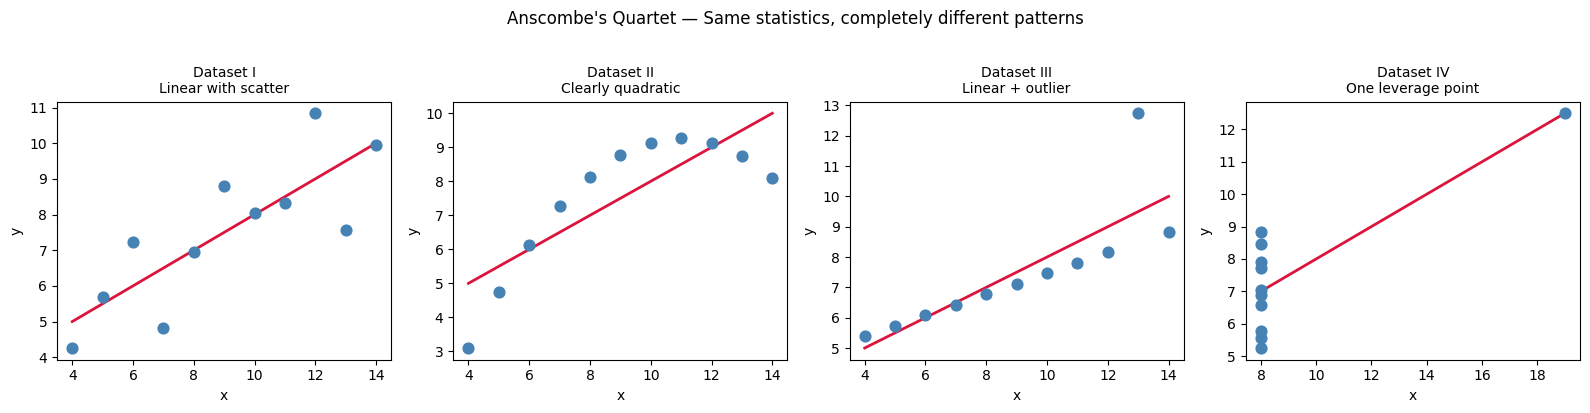

All four datasets have nearly identical: N=11, mean(x)=9.0, mean(y)=7.5,
regression slope≈0.5, intercept≈3.0, correlation≈0.816

Lesson: Never rely on summary statistics alone — always visualise!


In [3]:
# But visualising reveals completely different structures
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

descriptions = {
    'I':  'Linear with scatter',
    'II': 'Clearly quadratic',
    'III':'Linear + outlier',
    'IV': 'One leverage point',
}

for ax, (label, group) in zip(axes, anscombe.groupby('dataset')):
    ax.scatter(group['x'], group['y'], color='steelblue', s=60, zorder=3)
    # regression line
    m = ((group['x'] - group['x'].mean()) * (group['y'] - group['y'].mean())).sum() / \
        ((group['x'] - group['x'].mean()) ** 2).sum()
    b = group['y'].mean() - m * group['x'].mean()
    xr = [group['x'].min(), group['x'].max()]
    ax.plot(xr, [m * xi + b for xi in xr], color='crimson', linewidth=2)
    ax.set_title(f"Dataset {label}\n{descriptions[label]}", fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle("Anscombe's Quartet — Same statistics, completely different patterns", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("All four datasets have nearly identical: N=11, mean(x)=9.0, mean(y)=7.5,")
print("regression slope≈0.5, intercept≈3.0, correlation≈0.816")
print()
print("Lesson: Never rely on summary statistics alone — always visualise!")

## The Role of Graphics

EDA relies heavily on visualisation because graphics gives analysts unparalleled power to let data reveal its structure. Three categories of graphical techniques:

1. **Raw data plots** — histograms, scatter plots, data traces
2. **Summary statistic plots** — mean plots, box plots, standard deviation plots  
3. **Positioning** — multiple plots per page to leverage human pattern recognition

Statistical graphics ≠ EDA. EDA is the *philosophy*; graphics are its primary *tool*.

## Key Takeaways

| Concept | Key Point |
|---|---|
| EDA definition | Philosophy of letting data reveal its own structure |
| vs Classical | Classical imposes model first; EDA analyses first |
| Four goals | Pattern discovery, anomaly detection, assumption testing, feature insight |
| Pipeline | Collection → Cleaning → Profiling → Visualisation |
| Key lesson | Always visualise — summary statistics alone are misleading (Anscombe's Quartet) |